<a href="https://colab.research.google.com/github/KiruthikaVM2005/My-project/blob/main/houseprice.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [25]:
import pandas as pd

In [26]:
df = pd.read_csv('Housing.csv')
df.head()

,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus
0,13300000,7420,4,2,3,yes,no,no,no,yes,2,yes,furnished
1,12250000,8960,4,4,4,yes,no,no,no,yes,3,no,furnished
2,12250000,9960,3,2,2,yes,no,yes,no,no,2,yes,semi-furnished
3,12215000,7500,4,2,2,yes,no,yes,no,yes,3,yes,furnished
4,11410000,7420,4,1,2,yes,yes,yes,no,yes,2,no,furnished


In [27]:
df.describe()

,price,area,bedrooms,bathrooms,stories,parking
count,5.450000e+02,545.000000,545.000000,545.000000,545.000000,545.000000
mean,4.766729e+06,5150.541284,2.965138,1.286239,1.805505,0.693578
std,1.870440e+06,2170.141023,0.738064,0.502470,0.867492,0.861586
min,1.750000e+06,1650.000000,1.000000,1.000000,1.000000,0.000000
25%,3.430000e+06,3600.000000,2.000000,1.000000,1.000000,0.000000
50%,4.340000e+06,4600.000000,3.000000,1.000000,2.000000,0.000000
75%,5.740000e+06,6360.000000,3.000000,2.000000,2.000000,1.000000
max,1.330000e+07,16200.000000,6.000000,4.000000,4.000000,3.000000


In [28]:
df.isna().sum()

,0
price,0
area,0
bedrooms,0
bathrooms,0
stories,0
mainroad,0
guestroom,0
basement,0
hotwaterheating,0
airconditioning,0


In [29]:
transform=['mainroad','guestroom','basement','hotwaterheating','airconditioning','prefarea'	]
df[transform]=df[transform].replace({'yes':1,'no':0})
df.head()

/tmp/ipykernel_3074/1501348559.py:2: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df[transform]=df[transform].replace({'yes':1,'no':0})


,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus
0,13300000,7420,4,2,3,1,0,0,0,1,2,1,furnished
1,12250000,8960,4,4,4,1,0,0,0,1,3,0,furnished
2,12250000,9960,3,2,2,1,0,1,0,0,2,1,semi-furnished
3,12215000,7500,4,2,2,1,0,1,0,1,3,1,furnished
4,11410000,7420,4,1,2,1,1,1,0,1,2,0,furnished


In [30]:
df['furnishingstatus']=df['furnishingstatus'].replace({'unfurnished':0,'semi-furnished':1,'furnished':2})
df.head()

/tmp/ipykernel_3074/3354989351.py:1: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df['furnishingstatus']=df['furnishingstatus'].replace({'unfurnished':0,'semi-furnished':1,'furnished':2})


,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus
0,13300000,7420,4,2,3,1,0,0,0,1,2,1,2
1,12250000,8960,4,4,4,1,0,0,0,1,3,0,2
2,12250000,9960,3,2,2,1,0,1,0,0,2,1,1
3,12215000,7500,4,2,2,1,0,1,0,1,3,1,2
4,11410000,7420,4,1,2,1,1,1,0,1,2,0,2


In [31]:
from sklearn.preprocessing import StandardScaler

In [32]:
scalar=StandardScaler()
sc=['price','area']
df[sc]=scalar.fit_transform(df[sc])
df.head()

,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus
0,4.566365,1.046726,4,2,3,1,0,0,0,1,2,1,2
1,4.004484,1.757010,4,4,4,1,0,0,0,1,3,0,2
2,4.004484,2.218232,3,2,2,1,0,1,0,0,2,1,1
3,3.985755,1.083624,4,2,2,1,0,1,0,1,3,1,2
4,3.554979,1.046726,4,1,2,1,1,1,0,1,2,0,2


In [33]:
import matplotlib.pyplot as plt
import seaborn as sns

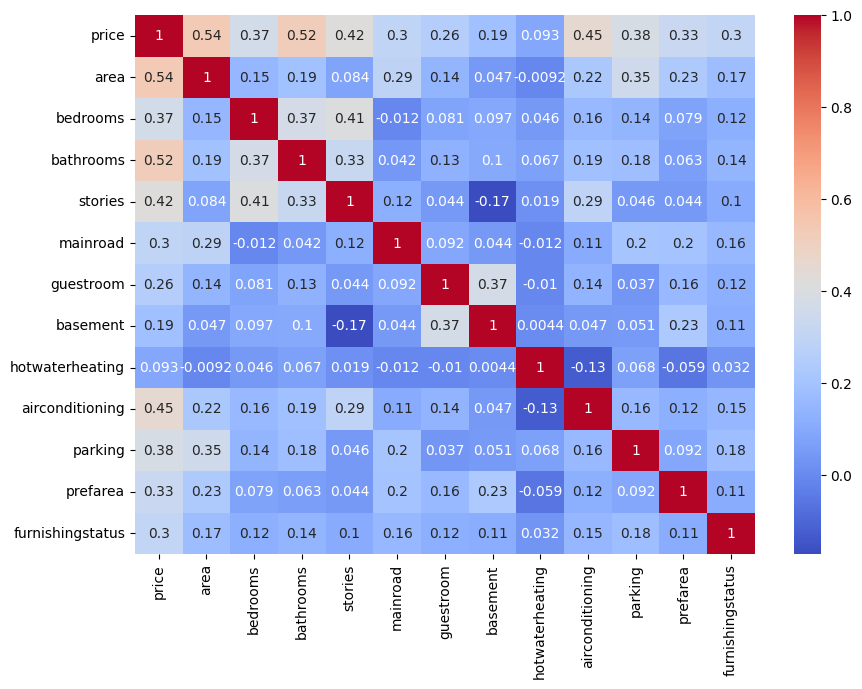

In [34]:
plt.figure(figsize=(10,7))
sns.heatmap(df.corr(),annot=True,cmap='coolwarm')
plt.show()


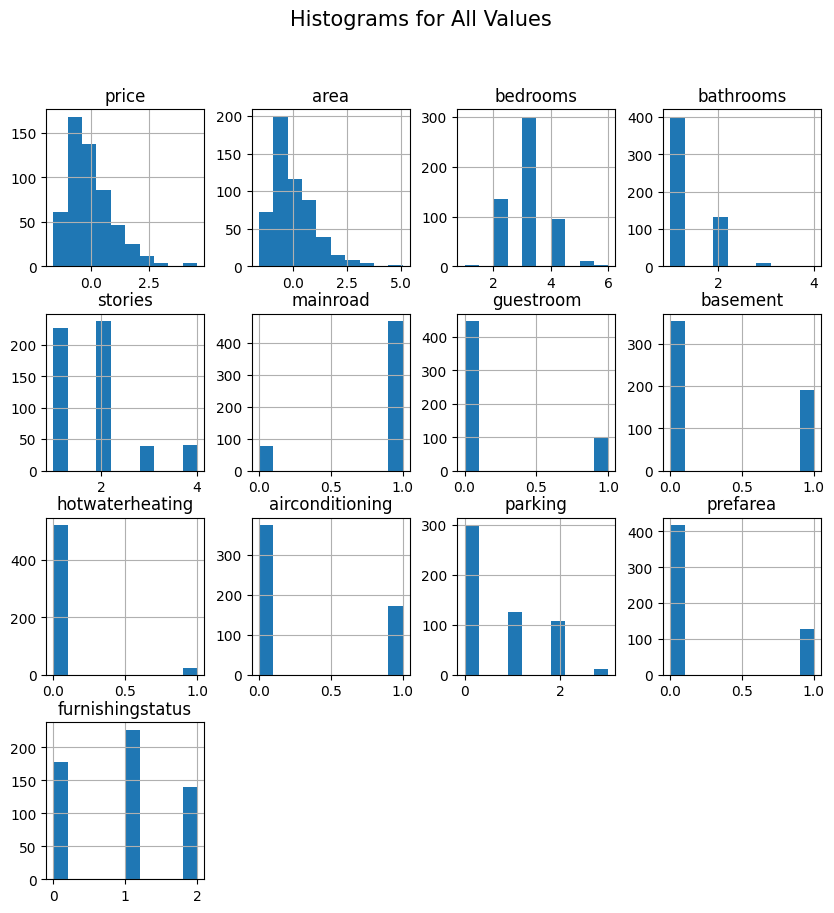

In [35]:
df.hist(figsize=(10,10),bins=10)
plt.suptitle('Histograms for All Values',fontsize=15)
plt.show()

In [36]:
from sklearn.model_selection import train_test_split
x=df.drop('price',axis=1)
y=df['price']
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=42)

In [37]:
from sklearn.linear_model import LinearRegression
lr_model=LinearRegression()
lr_model.fit(x_train,y_train)
y_pred = lr_model.predict(x_test)

In [38]:
lr_y_pred = lr_model.predict(x_test)

In [39]:
from sklearn.metrics import r2_score
lr_accuracy = r2_score(y_test, lr_y_pred)*100
lr_accuracy

64.94754192267794

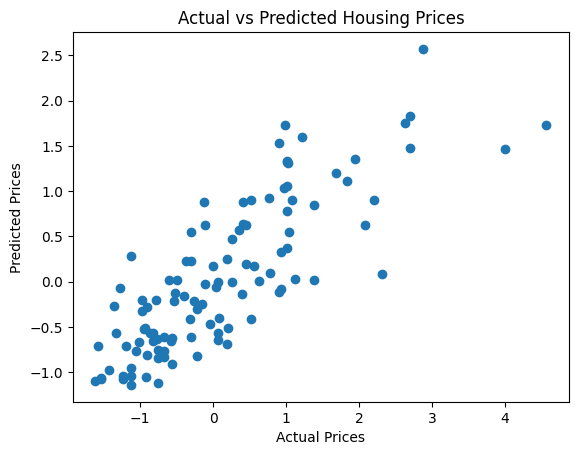

In [40]:
import matplotlib.pyplot as plt

plt.scatter(y_test, lr_y_pred)
plt.xlabel("Actual Prices")
plt.ylabel("Predicted Prices")
plt.title("Actual vs Predicted Housing Prices")
plt.show()

In [41]:
import numpy as np

In [24]:
original_df = pd.read_csv('Housing.csv')
scalar = StandardScaler()
scalar.fit(original_df[['price', 'area']])
print("--- Enter House Details ---")
area = float(input("Area (sqft): "))
bedrooms = int(input("Bedrooms count: "))
bathrooms = int(input("Bathrooms count: "))
stories = int(input("Stories count: "))
parking = int(input("Parking slots: "))
mainroad_input = input("On Mainroad? (yes/no): ").lower()
mainroad = 1 if mainroad_input == 'yes' else 0

guestroom_input = input("Has Guestroom? (yes/no): ").lower()
guestroom = 1 if guestroom_input == 'yes' else 0

basement_input = input("Has Basement? (yes/no): ").lower()
basement = 1 if basement_input == 'yes' else 0

hotwater_input = input("Has Hotwater heating? (yes/no): ").lower()
hotwater = 1 if hotwater_input == 'yes' else 0

ac_input = input("Has Air conditioning? (yes/no): ").lower()
ac = 1 if ac_input == 'yes' else 0

prefarea_input = input("Is in Preferred area? (yes/no): ").lower()
prefarea = 1 if prefarea_input == 'yes' else 0

furnishing = input("Furnishing status (furnished / semi-furnished / unfurnished): ").lower()
furnish_map = {'furnished': 2, 'semi-furnished': 1, 'unfurnished': 0}
furnish_val = furnish_map.get(furnishing, 0)

scaled_input = scalar.transform([[0, area]])
scaled_area = scaled_input[0][1]

final_input = [[scaled_area, bedrooms, bathrooms, stories, mainroad, guestroom, basement, hotwater, ac, parking, prefarea, furnish_val]]

prediction_scaled = lr_model.predict(final_input)

real_price_output = scalar.inverse_transform([[prediction_scaled[0], 0]])[0][0]

print("\n Predicted House Price:")
print(real_price_output)

--- Enter House Details ---
Area (sqft): 7000
Bedrooms count: 3
Bathrooms count: 4
Stories count: 2
Parking slots: 2
On Mainroad? (yes/no): yes
Has Guestroom? (yes/no): yes
Has Basement? (yes/no): yes
Has Hotwater heating? (yes/no): yes
Has Air conditioning? (yes/no): no
Is in Preferred area? (yes/no): no
Furnishing status (furnished / semi-furnished / unfurnished): unfurnished

 Predicted House Price:
9092394.181459367


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(
